In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, zipfile
import geopandas as gpd
import pyogrio
import folium
from pathlib import Path

plt.style.use("ggplot")
DATA      = Path("data")
NFHL_PATH = DATA / "NFHL_34_20250903/NFHL_34_20250903.gdb"

In [2]:
# Load 2023 parcels only — one geometry per gis_pin, most current boundaries
parcels_2023 = gpd.read_parquet(
    DATA / "parcels_shore.parquet",
    filters=[("mod_iv_year", "==", 2023)],
    columns=["gis_pin", "geometry"],
)
# representative_point() always falls inside the polygon (unlike centroid for concave shapes)
parcel_pts = parcels_2023.copy()
parcel_pts["geometry"] = parcels_2023.geometry.representative_point()
print(f"Unique parcels: {len(parcel_pts):,}  CRS: {parcel_pts.crs}")

Unique parcels: 442,588  CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "CompoundCRS", "name": "NAD83 / New Jersey (ftUS) + NAVD88 height (ftUS)", "components": [{"type": "ProjectedCRS", "name": "NAD83 / New Jersey (ftUS)", "base_crs": {"name": "NAD83", "datum": {"type": "GeodeticReferenceFrame", "name": "North American Datum 1983", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4269}}, "conversion": {"name": "unnamed", "method": {"name": "Transverse Mercator", "id": {"authority": "EPSG", "code": 9807}}, "parameters": [{"name": "Latitude of natural origin", "value": 38.8333333333333, "unit": "degree", "id": {"authority": "E

In [3]:
# Load full NJ statewide flood hazard zones, reproject to match parcels (EPSG:3424)
nfhl_zones = (
    gpd.read_file(NFHL_PATH, layer="S_FLD_HAZ_AR", engine="pyogrio")
    .to_crs(3424)
)
# Clip to parcel bbox — reduces 57k rows to only those covering the NJ shore
nfhl_zones = nfhl_zones.clip(parcel_pts.total_bounds)
print(f"NFHL flood zones after clip: {len(nfhl_zones):,}")
print(nfhl_zones[["FLD_ZONE", "ZONE_SUBTY"]].head(10).to_string())

/opt/miniconda3/envs/default_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


NFHL flood zones after clip: 26,367
      FLD_ZONE                          ZONE_SUBTY
23516       VE                                None
32119        X  0.2 PCT ANNUAL CHANCE FLOOD HAZARD
23531       VE                                None
32118        X  0.2 PCT ANNUAL CHANCE FLOOD HAZARD
5504        AE                                None
32117        X  0.2 PCT ANNUAL CHANCE FLOOD HAZARD
32115        X  0.2 PCT ANNUAL CHANCE FLOOD HAZARD
32116        X  0.2 PCT ANNUAL CHANCE FLOOD HAZARD
5579        AE                                None
32114        X  0.2 PCT ANNUAL CHANCE FLOOD HAZARD


In [4]:
# Left join keeps all parcels; those outside any zone get NaN → 'Undetermined'
joined = gpd.sjoin(
    parcel_pts[["gis_pin", "geometry"]],
    nfhl_zones[["FLD_ZONE", "ZONE_SUBTY", "geometry"]],
    how="left",
    predicate="within",
)
joined = joined.drop(columns=["index_right"], errors="ignore")
# A centroid on a zone boundary could match two zones; keep first occurrence
joined = joined.drop_duplicates(subset="gis_pin", keep="first")

print(f"Joined rows: {len(joined):,}  (expected {len(parcel_pts):,})")
print(joined["FLD_ZONE"].value_counts(dropna=False).head(10))

/var/folders/lf/1r0cw2qs3pq870f2x7yb20w40000gn/T/ipykernel_71324/818103854.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:8760
Right CRS: EPSG:3424

  joined = gpd.sjoin(


Joined rows: 442,588  (expected 442,588)
FLD_ZONE
X                    266627
AE                   118156
AREA NOT INCLUDED     50316
AO                     4233
VE                     2450
NaN                     410
A                       327
D                        69
Name: count, dtype: int64


In [5]:
HIGH_ZONES = {"A", "A99", "AE", "AH", "AO", "V", "VE"}

def classify_risk(zone, subty):
    if pd.isna(zone) or zone in {"AREA NOT INCLUDED", "OPEN WATER"}:
        return "Undetermined"
    if zone in HIGH_ZONES:
        return "High"
    if zone == "X":
        s = str(subty).upper() if pd.notna(subty) else ""
        return "Moderate" if ("0.2" in s or "SHADED" in s) else "Low"
    return "Undetermined"

joined["flood_risk"] = joined.apply(
    lambda r: classify_risk(r["FLD_ZONE"], r["ZONE_SUBTY"]), axis=1
)
print(joined["flood_risk"].value_counts())

flood_risk
Low             243835
High            125166
Undetermined     50795
Moderate         22792
Name: count, dtype: int64


In [6]:
COAST_DIR = DATA / "tl_2023_us_coastline"
COAST_ZIP = DATA / "tl_2023_us_coastline.zip"
COAST_URL = "https://www2.census.gov/geo/tiger/TIGER2023/COASTLINE/tl_2023_us_coastline.zip"

if not COAST_DIR.exists():
    print("Downloading TIGER coastline (~8 MB)...")
    urllib.request.urlretrieve(COAST_URL, COAST_ZIP)
    with zipfile.ZipFile(COAST_ZIP) as z:
        z.extractall(COAST_DIR)
    COAST_ZIP.unlink()
    print("Done.")

coastline = gpd.read_file(COAST_DIR).to_crs(3424)
import shapely
buf = shapely.box(*parcel_pts.total_bounds).buffer(50_000)
coastline_clip = coastline.clip(buf)
coast_geom = coastline_clip.geometry.union_all()   # single MultiLineString
print(f"Coastline segments after clip: {len(coastline_clip):,}")

Coastline segments after clip: 10


In [7]:
# EPSG:3424 units are US survey feet; 1 mile = 5280 ft
# Reset index so the GeoSeries and joined DataFrame stay aligned
joined = joined.reset_index(drop=True)
pts_geom = (
    parcel_pts.set_index("gis_pin")
    .loc[joined["gis_pin"].values, "geometry"]
    .reset_index(drop=True)   # GeoSeries with CRS inherited; align to joined's RangeIndex
)
joined["dist_to_ocean_mi"] = pts_geom.distance(coast_geom) / 5280
print(joined["dist_to_ocean_mi"].describe())

count    442588.000000
mean          3.455402
std           3.302581
min           0.000063
25%           0.510455
50%           2.625565
75%           5.581481
max          16.160142
Name: dist_to_ocean_mi, dtype: float64


In [8]:
flood_feats = joined[["gis_pin", "FLD_ZONE", "ZONE_SUBTY", "flood_risk", "dist_to_ocean_mi"]].copy()

In [9]:
import duckdb

con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

# Register in-memory features — no intermediate parquet file needed
con.register("flood_feats_tbl", flood_feats)

tmp_out = DATA / "parcels_shore_tmp.parquet"
con.execute(f"""
COPY (
    SELECT p.*, f.FLD_ZONE, f.ZONE_SUBTY, f.flood_risk, f.dist_to_ocean_mi
    FROM read_parquet('{DATA}/parcels_shore.parquet') p
    LEFT JOIN flood_feats_tbl f ON p.gis_pin = f.gis_pin
) TO '{tmp_out}'
(FORMAT PARQUET, COMPRESSION ZSTD);
""")
con.close()

tmp_out.replace(DATA / "parcels_shore.parquet")
print("Updated parcels_shore.parquet with flood features")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Updated parcels_shore.parquet with flood features


In [10]:
print("=== flood_risk distribution ===")
print(flood_feats["flood_risk"].value_counts())
print("\n=== FLD_ZONE distribution ===")
print(flood_feats["FLD_ZONE"].value_counts(dropna=False))
print("\n=== dist_to_ocean_mi summary ===")
print(flood_feats["dist_to_ocean_mi"].describe().round(3))

=== flood_risk distribution ===
flood_risk
Low             243835
High            125166
Undetermined     50795
Moderate         22792
Name: count, dtype: int64

=== FLD_ZONE distribution ===
FLD_ZONE
X                    266627
AE                   118156
AREA NOT INCLUDED     50316
AO                     4233
VE                     2450
NaN                     410
A                       327
D                        69
Name: count, dtype: int64

=== dist_to_ocean_mi summary ===
count    442588.000
mean          3.455
std           3.303
min           0.000
25%           0.510
50%           2.626
75%           5.581
max          16.160
Name: dist_to_ocean_mi, dtype: float64


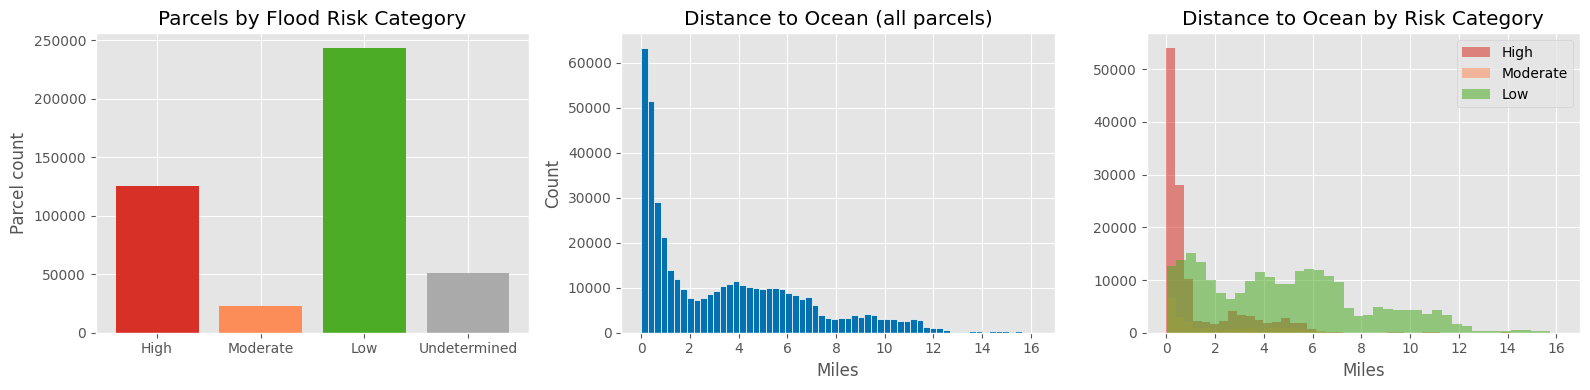

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))



risk_order = ["High", "Moderate", "Low", "Undetermined"]
counts = flood_feats["flood_risk"].value_counts().reindex(risk_order)
axes[0].bar(counts.index, counts.values,
            color=["#d73027", "#fc8d59", "#4dac26", "#aaaaaa"])
axes[0].set_title("Parcels by Flood Risk Category")
axes[0].set_ylabel("Parcel count")

axes[1].hist(flood_feats["dist_to_ocean_mi"].dropna(), bins=60,
             color="#0571b0", edgecolor="white")
axes[1].set_title("Distance to Ocean (all parcels)")
axes[1].set_xlabel("Miles")
axes[1].set_ylabel("Count")

for cat, col in zip(["High", "Moderate", "Low"], ["#d73027", "#fc8d59", "#4dac26"]):
    sub = flood_feats.loc[flood_feats["flood_risk"] == cat, "dist_to_ocean_mi"].dropna()
    axes[2].hist(sub, bins=40, alpha=0.55, label=cat, color=col)
axes[2].set_title("Distance to Ocean by Risk Category")
axes[2].set_xlabel("Miles")
axes[2].legend()

plt.tight_layout()
plt.show()